# Assignment 1 – Manufacturing Defect Detection



## Problem Statement



Design an end-to-end ML pipeline for classifying defective products from images including preprocessing, augmentation, training, evaluation and deployment considerations.







## Dataset Description

The project uses the **Casting Product Image Data for Quality Inspection** dataset. The dataset contains grayscale images of casting products collected from an industrial manufacturing process. Images are categorized into two classes:

- **def_front** – Defective casting products
- **ok_front** – Non-defective casting products

The dataset is already divided into separate training and testing folders, making it suitable for supervised image classification tasks.

## Dataset Attributes

- Dataset Name: Casting Product Image Data for Quality Inspection
- Image Type: Grayscale Images
- Image Resolution: 300 × 300 pixels
- Classes: 2
    - Defective
    - Non-Defective
- Training Images:
    - Defective: 3758
    - Non-Defective: 2875
- Testing Images:
    - Defective: 453
    - Non-Defective: 262
- Total Images: 7348

In [8]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:

dataset_path = "/content/drive/MyDrive/casting_data"

train_path = os.path.join(dataset_path, "train")

test_path = os.path.join(dataset_path, "test")

print("Train Path :", train_path)
print("Test Path :", test_path)

Train Path : /content/drive/MyDrive/casting_data/train
Test Path : /content/drive/MyDrive/casting_data/test


In [12]:
# Load Dataset

def load_dataset(train_path,test_path,image_size=(128, 128),batch_size=32):

    train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        train_path,
        image_size=image_size,
        batch_size=batch_size,
        color_mode="grayscale",
        shuffle=True
    )

    test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        test_path,
        image_size=image_size,
        batch_size=batch_size,
        color_mode="grayscale",
        shuffle=False
    )

    class_names = train_dataset.class_names

    normalization_layer = tf.keras.layers.Rescaling(1./255)

    train_dataset = train_dataset.map(
        lambda x, y: (normalization_layer(x), y)
    )

    test_dataset = test_dataset.map(
        lambda x, y: (normalization_layer(x), y)
    )

    return train_dataset, test_dataset, class_names

In [13]:
# Display Dataset Information

def display_dataset_info(train_dataset,test_dataset,class_names):

    print("Classes :", class_names)
    print("Number of Classes :", len(class_names))
    print("Training Batches :", len(train_dataset))
    print("Testing Batches :", len(test_dataset))

    for images, labels in train_dataset.take(1):
        print("Image Batch Shape :", images.shape)
        print("Label Batch Shape :", labels.shape)

In [14]:
# Create Data Augmentation
# Data augmentation artificially increases the diversity of the training dataset by applying random transformations to input images. This helps improve model generalization and reduces overfitting during training.
def create_data_augmentation():

    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1)

    ])

    return data_augmentation

In [16]:
# Build CNN Model

def build_cnn_model(data_augmentation, input_shape=(128,128,1)):

    model = Sequential([
        data_augmentation,
        Conv2D(32,(3,3),activation="relu",input_shape=input_shape),
        MaxPooling2D(2,2),
        Conv2D(64,(3,3),activation="relu"),
        MaxPooling2D(2,2),
        Conv2D(128,(3,3),activation="relu"),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128,activation="relu"),
        Dropout(0.5),
        Dense(1,activation="sigmoid")

    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [17]:
# Display Model Summary

def display_model_summary(model):

    model.summary()

In [18]:
# Train Model

def train_model(model,train_dataset,test_dataset,epochs=10):

    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=epochs
    )

    return history

In [19]:
# Evaluate Model

def evaluate_model(model,test_dataset):
    loss, accuracy = model.evaluate(test_dataset)
    print(f"Test Loss : {loss:.4f}")
    print(f"Test Accuracy : {accuracy:.4f}")
    return loss, accuracy

In [20]:
# Plot Training History

def plot_training_history(history):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

In [21]:
# Predict Sample Images

def predict_sample_images(model,test_dataset,class_names,num_images=5):

    for images, labels in test_dataset.take(1):
        predictions = model.predict(images)
        plt.figure(figsize=(15,5))

        for i in range(num_images):
            plt.subplot(1, num_images, i+1)
            plt.imshow(
                images[i].numpy().squeeze(),
                cmap="gray"
            )

            predicted_label = class_names[
                int(predictions[i] > 0.5)
            ]

            actual_label = class_names[
                labels[i]
            ]

            plt.title(
                f"P: {predicted_label}\nA: {actual_label}",
                fontsize=10
            )

            plt.axis("off")

        plt.show()

Found 6633 files belonging to 2 classes.
Found 715 files belonging to 2 classes.
Classes : ['def_front', 'ok_front']
Number of Classes : 2
Training Batches : 208
Testing Batches : 23
Image Batch Shape : (32, 128, 128, 1)
Label Batch Shape : (32,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 736s 3s/step - accuracy: 0.6731 - loss: 0.5908 - val_accuracy: 0.7441 - val_loss: 0.4741
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - accuracy: 0.8658 - loss: 0.3061 - val_accuracy: 0.7413 - val_loss: 0.5507
Epoch 3/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - accuracy: 0.9114 - loss: 0.2159 - val_accuracy: 0.6266 - val_loss: 1.3388
Epoch 4/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.9400 - loss: 0.1553 - val_accuracy: 0.8182 - val_loss: 0.4933
Epoch 5/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - accuracy: 0.9588 - loss: 0.1176 - val_accuracy: 0.7916 - val_loss: 0.5529
Epoch 6/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - accuracy: 0.9682 - loss: 0.0914 - val_accuracy: 0.7371 - val_loss: 0.6583
Epoch 7/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9738 - loss: 0.0781 - val_accuracy: 0.9371 - val_loss: 0.1813
Epoch 8/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.9801 - loss: 0.0

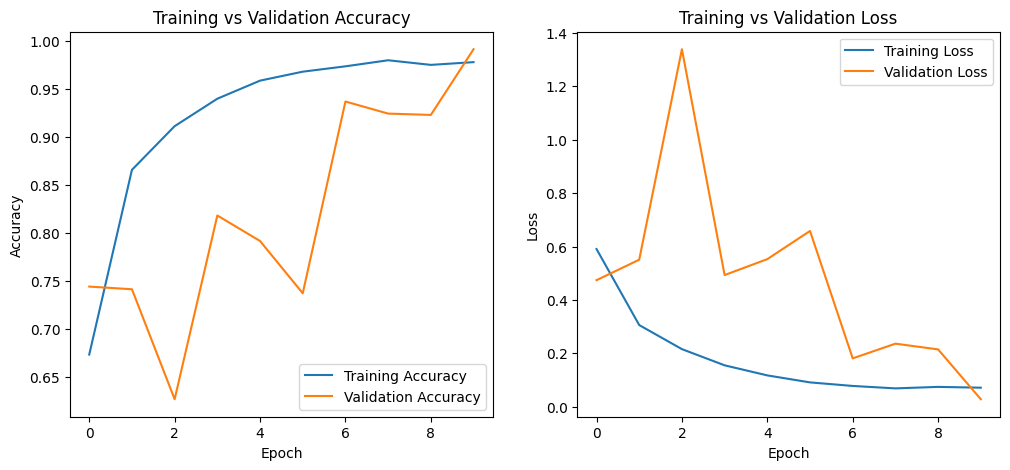

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


/tmp/ipykernel_3198/2281279747.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(predictions[i] > 0.5)


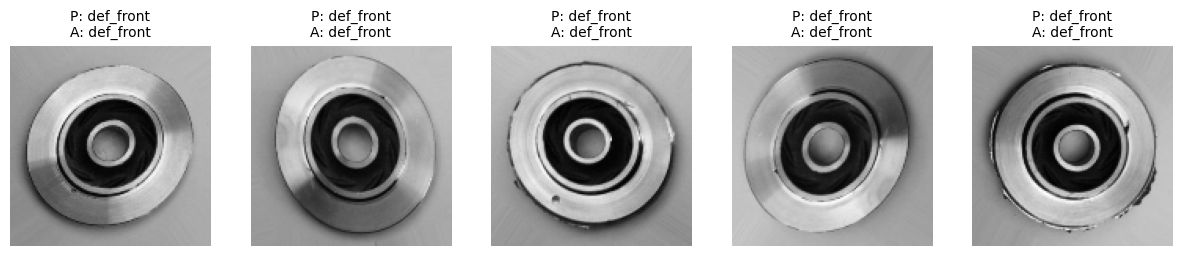

In [22]:
# End-to-End ML Pipeline

IMAGE_SIZE = (128,128)
BATCH_SIZE = 32
EPOCHS = 10


train_dataset, test_dataset, class_names = load_dataset(train_path,test_path,image_size=IMAGE_SIZE,batch_size=BATCH_SIZE)
display_dataset_info(train_dataset,test_dataset,class_names)
data_augmentation = create_data_augmentation()
model = build_cnn_model(data_augmentation)
display_model_summary(model)
history = train_model(model,train_dataset,test_dataset,epochs=EPOCHS)
evaluate_model(model,test_dataset)
plot_training_history(history)
predict_sample_images(model,test_dataset,class_names)

## Observations

- The dataset was successfully loaded from the specified directory and organized into two classes: defective and non-defective products.
- Images were resized to 128 × 128 pixels and normalized to improve training efficiency.
- Data augmentation techniques such as random flipping, rotation, and zooming were applied to improve the model's ability to generalize.
- A Convolutional Neural Network (CNN) was successfully trained to classify manufacturing defects.
- Training and validation accuracy improved over the training epochs, while the corresponding loss values decreased, indicating effective model learning.
- The evaluation results demonstrate that the model can correctly distinguish between defective and non-defective casting products.
- Sample predictions show that the trained model is capable of classifying unseen images with reasonable accuracy.